In [9]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
df = pd.read_csv('../dataset.csv')

df['CLASS'] = df['CLASS'].str.strip()         
df['Gender'] = df['Gender'].str.strip().str.upper()  # normalize 'f' -> 'F'

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (1000, 14)
Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [14]:
print('Missing values per column:')
print(df.isnull().sum())

print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

Total missing values: 0


In [15]:
print(f'Duplicate rows: {df.duplicated().sum()}')

# Unique values in categorical columns
print(f"\nGender values: {df['Gender'].unique()}")
print(f"CLASS values:  {df['CLASS'].unique()}")

Duplicate rows: 0

Gender values: ['F' 'M']
CLASS values:  ['N' 'P' 'Y']


In [18]:
numerical_cols = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

df[numerical_cols].describe().round(2)


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,53.53,5.12,68.94,8.28,4.86,2.35,1.20,2.61,1.85,29.58
std,8.80,2.94,59.98,2.53,1.30,1.40,0.66,1.12,3.66,4.96
min,20.00,0.50,6.00,0.90,0.00,0.30,0.20,0.30,0.10,19.00
25%,51.00,3.70,48.00,6.50,4.00,1.50,0.90,1.80,0.70,26.00
50%,55.00,4.60,60.00,8.00,4.80,2.00,1.10,2.50,0.90,30.00
75%,59.00,5.70,73.00,10.20,5.60,2.90,1.30,3.30,1.50,33.00
max,79.00,38.90,800.00,16.00,10.30,13.80,9.90,9.90,35.00,47.75


In [19]:
print('Mean values by CLASS:')
df.groupby('CLASS')[numerical_cols].mean().round(2)

Mean values by CLASS:


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,
N,44.23,4.68,62.80,4.56,4.27,1.63,1.23,2.63,0.94,22.37
P,43.28,4.51,66.08,6.00,4.58,2.13,1.13,2.49,0.98,23.93
Y,55.31,5.22,69.87,8.88,4.95,2.45,1.21,2.62,2.02,30.81


In [20]:
#class and gender distribution

print('CLASS distribution:')
print(df['CLASS'].value_counts())
print()
print('Gender distribution:')
print(df['Gender'].value_counts())

CLASS distribution:
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64

Gender distribution:
Gender
M    565
F    435
Name: count, dtype: int64


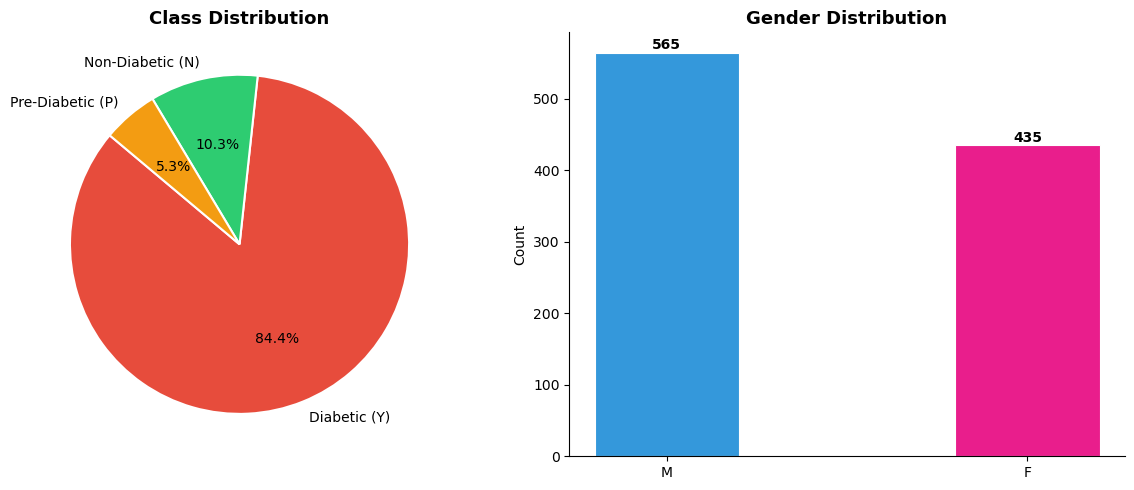

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class distribution
class_counts = df['CLASS'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#f39c12']
axes[0].pie(
    class_counts,
    labels=['Diabetic (Y)', 'Non-Diabetic (N)', 'Pre-Diabetic (P)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values,
            color=['#3498db', '#e91e8c'], edgecolor='white', linewidth=0.8, width=0.4)
axes[1].set_title('Gender Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (label, val) in enumerate(zip(gender_counts.index, gender_counts.values)):
    axes[1].text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Class breakdown by gender
ct = pd.crosstab(df['Gender'], df['CLASS'])
print('Count:')
print(ct)
print()
print('Row percentage (within each gender):')
print(ct.div(ct.sum(axis=1), axis=0).round(3) * 100)

Count:
CLASS    N   P    Y
Gender             
F       64  17  354
M       39  36  490

Row percentage (within each gender):
CLASS      N    P     Y
Gender                 
F       14.7  3.9  81.4
M        6.9  6.4  86.7


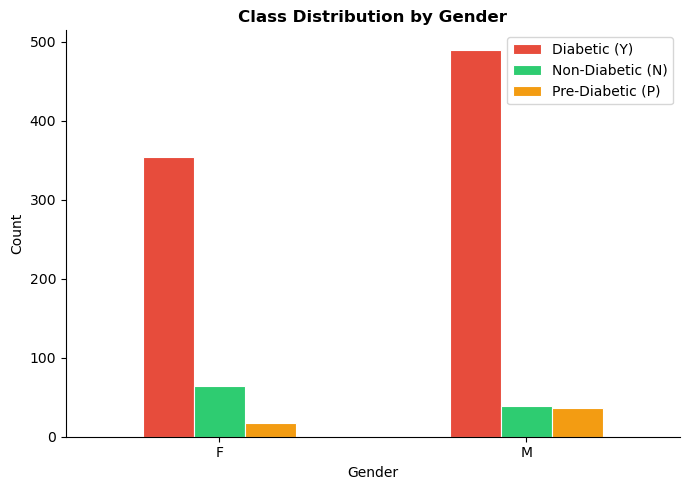

In [24]:
ct[['Y', 'N', 'P']].plot(kind='bar', figsize=(7, 5), color=['#e74c3c', '#2ecc71', '#f39c12'],
        edgecolor='white', linewidth=0.8)
plt.title('Class Distribution by Gender', fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Diabetic (Y)', 'Non-Diabetic (N)', 'Pre-Diabetic (P)'])
plt.tight_layout()
plt.show()

In [27]:
# Age group breakdown
bins = [0, 30, 45, 60, 100]
labels = ['< 30', '30 – 45', '45 – 60', '60+']
df['AgeGroup'] = pd.cut(df['AGE'], bins=bins, labels=labels)

age_class = pd.crosstab(df['AgeGroup'], df['CLASS'])
print('Count per age group:')
print(age_class)
print()
print('% Diabetic per age group:')
print((age_class['Y'] / age_class.sum(axis=1) * 100).round(1))

Count per age group:
CLASS      N   P    Y
AgeGroup             
< 30       8   4   15
30 – 45   49  21   56
45 – 60   43  28  628
60+        3   0  145

% Diabetic per age group:
AgeGroup
< 30       55.6
30 – 45    44.4
45 – 60    89.8
60+        98.0
dtype: float64


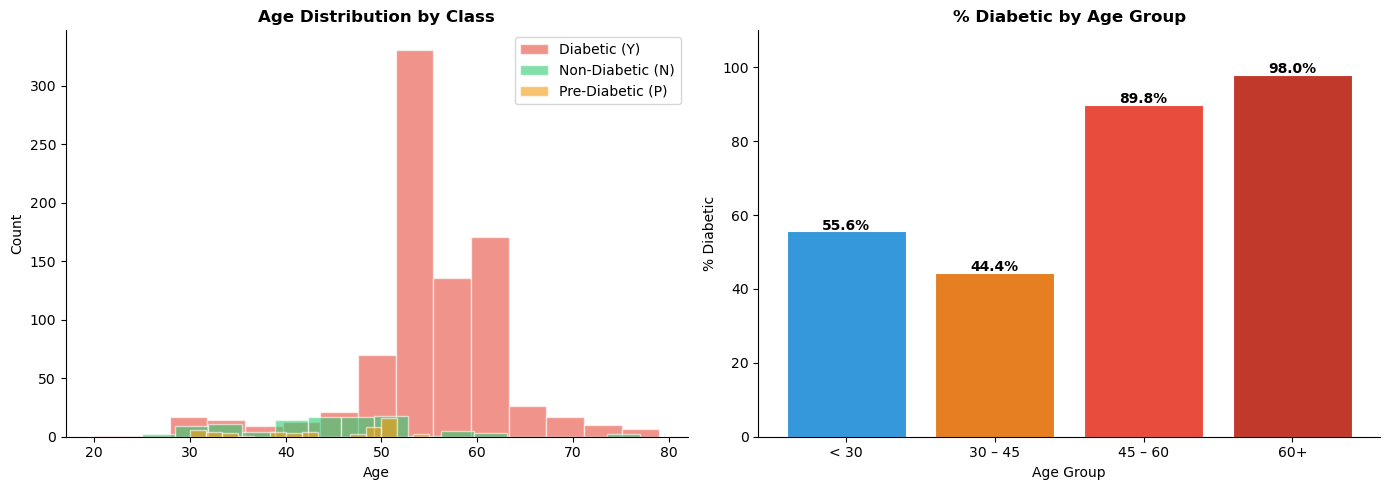

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram by class
for cls, color in zip(['Y', 'N', 'P'], ['#e74c3c', '#2ecc71', '#f39c12']):
    axes[0].hist(df[df['CLASS'] == cls]['AGE'], bins=15, alpha=0.6,
                 color=color, label=cls, edgecolor='white')
axes[0].set_title('Age Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend(['Diabetic (Y)', 'Non-Diabetic (N)', 'Pre-Diabetic (P)'])

# Diabetic rate by age group
diabetic_rate = (age_class['Y'] / age_class.sum(axis=1) * 100).reset_index()
diabetic_rate.columns = ['AgeGroup', 'DiabRate']
bars = axes[1].bar(diabetic_rate['AgeGroup'], diabetic_rate['DiabRate'],
                   color=['#3498db', '#e67e22', '#e74c3c', '#c0392b'],
                   edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, diabetic_rate['DiabRate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('% Diabetic by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('% Diabetic')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()

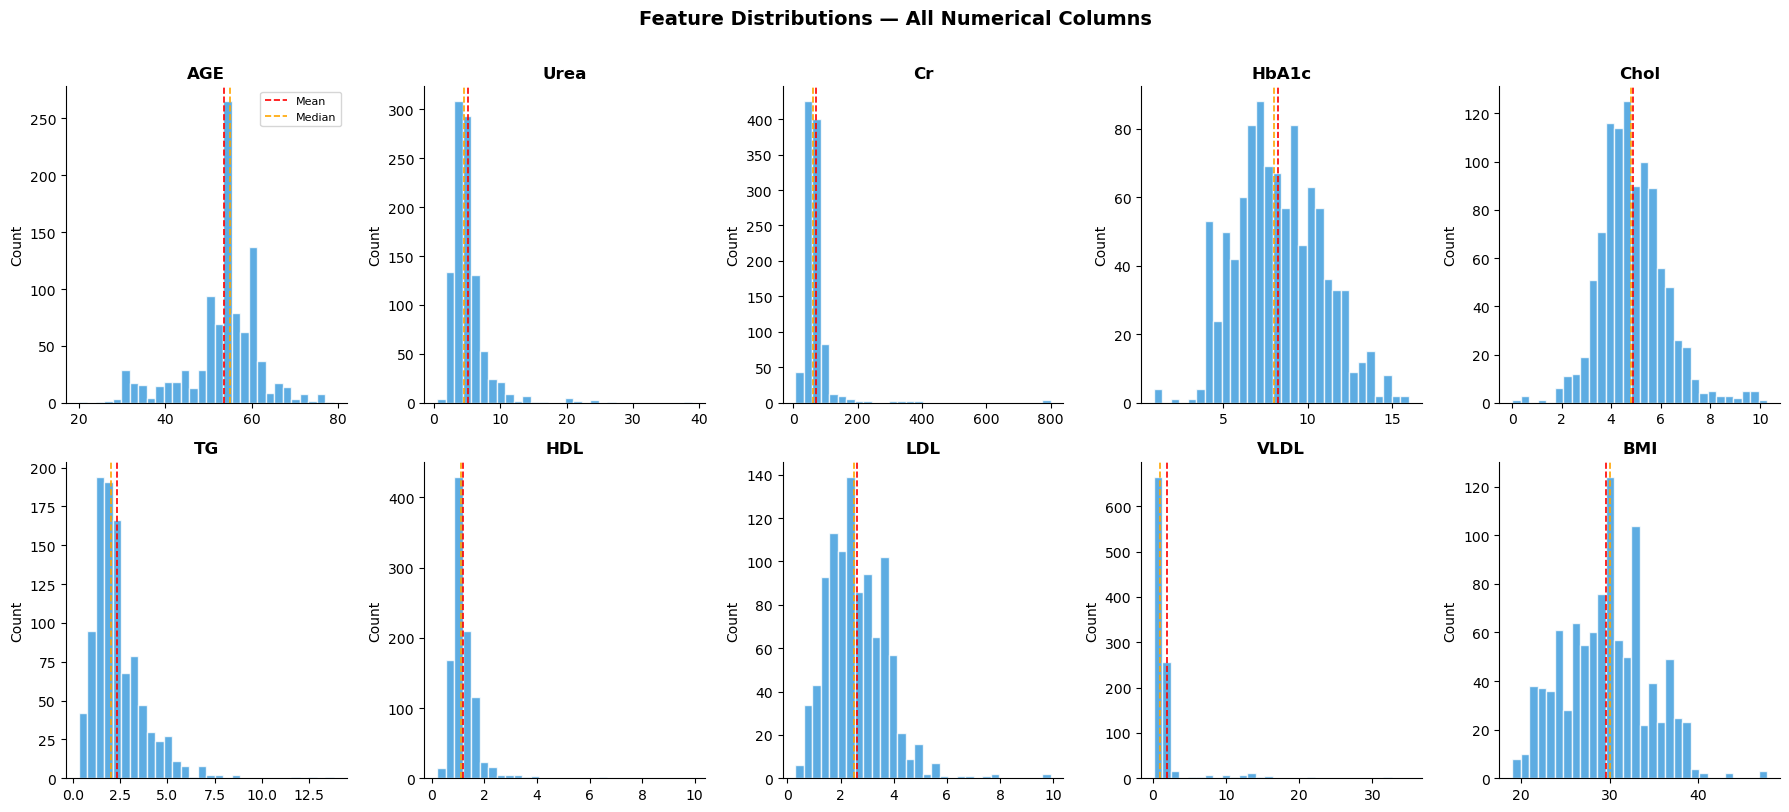

In [29]:
# Histograms for all numerical features
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.2, label='Median')

axes[0].legend(fontsize=8)
fig.suptitle('Feature Distributions — All Numerical Columns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

C:\Users\nohas\AppData\Local\Temp\ipykernel_23848\3715974401.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CLASS', y=col, order=class_order,
C:\Users\nohas\AppData\Local\Temp\ipykernel_23848\3715974401.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CLASS', y=col, order=class_order,
C:\Users\nohas\AppData\Local\Temp\ipykernel_23848\3715974401.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CLASS', y=col, order=class_order,
C:\Users\nohas\AppData\Local\Temp\ipykernel_23848\3715974401.py:11:

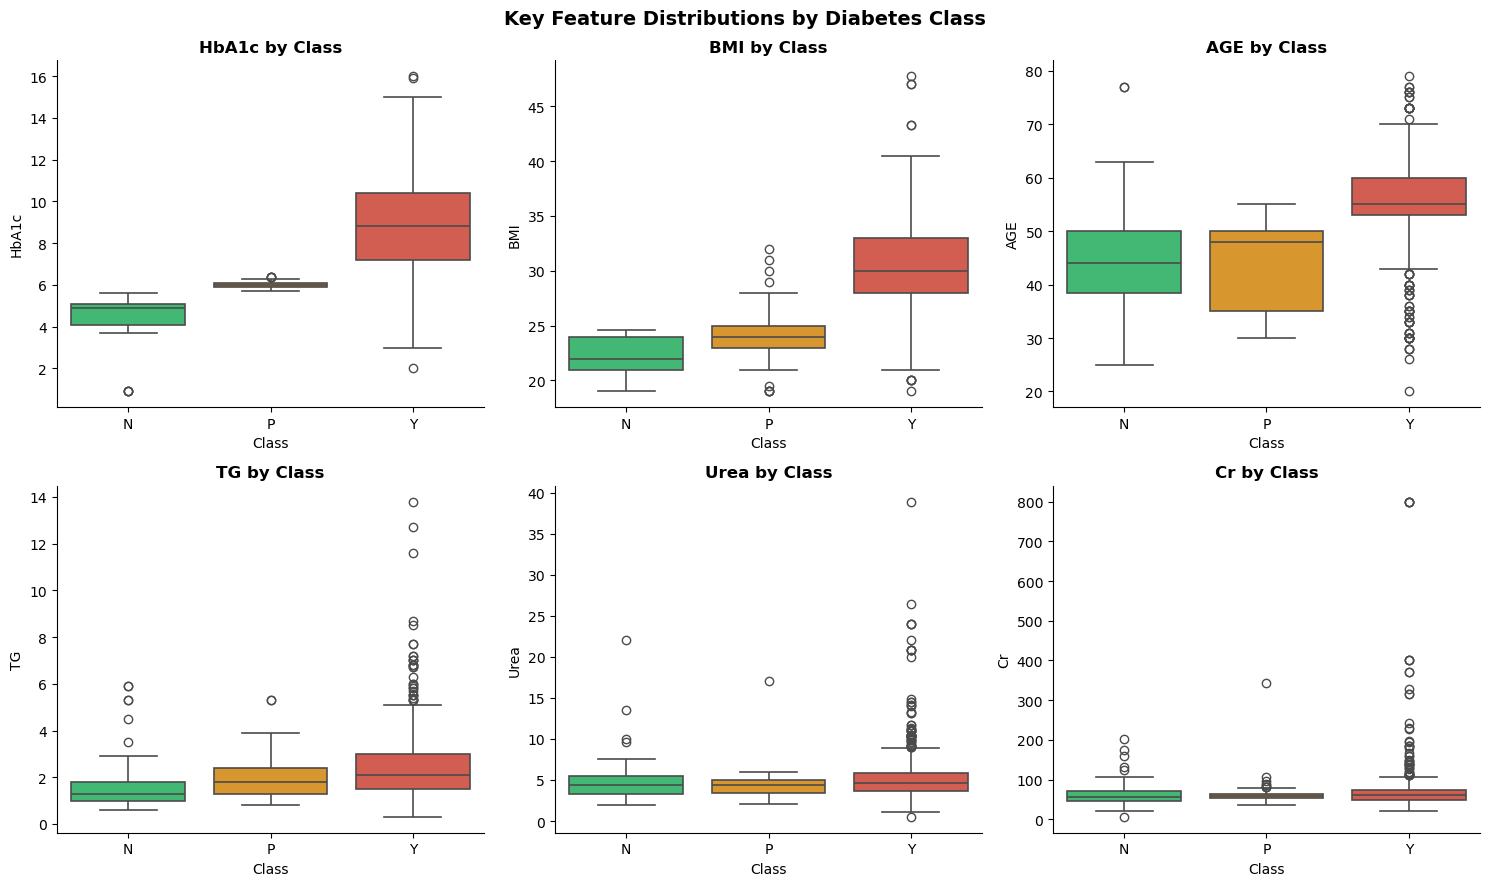

In [30]:
# Boxplots by class for key features
key_features = ['HbA1c', 'BMI', 'AGE', 'TG', 'Urea', 'Cr']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

class_order = ['N', 'P', 'Y']
palette = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='CLASS', y=col, order=class_order,
                palette=palette, ax=axes[i], linewidth=1.2)
    axes[i].set_title(f'{col} by Class', fontweight='bold')
    axes[i].set_xlabel('Class')

fig.suptitle('Key Feature Distributions by Diabetes Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

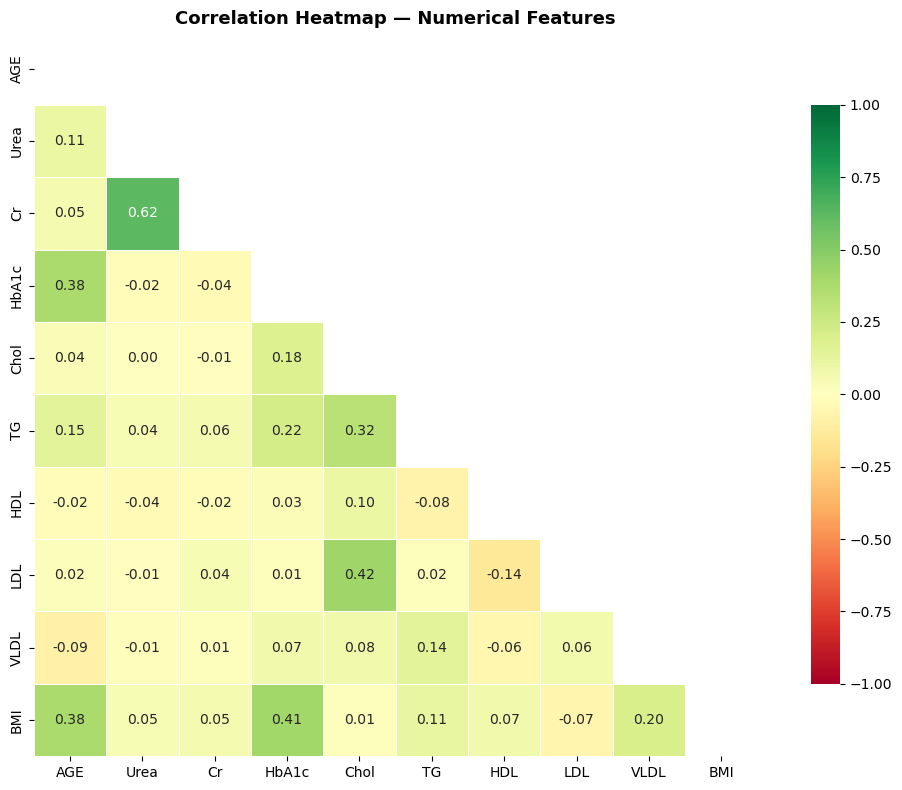

In [32]:
#correlation analysis
corr = df[numerical_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Print the strongest correlations (excluding self-correlations)
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs['Abs'] = corr_pairs['Correlation'].abs()
print('Top 10 strongest feature correlations:')
print(corr_pairs.sort_values('Abs', ascending=False).drop('Abs', axis=1).head(10).to_string(index=False))

Top 10 strongest feature correlations:
Feature 1 Feature 2  Correlation
       Cr      Urea     0.624134
      LDL      Chol     0.416665
      BMI     HbA1c     0.413350
    HbA1c       AGE     0.379136
      BMI       AGE     0.375956
       TG      Chol     0.321789
       TG     HbA1c     0.218556
      BMI      VLDL     0.198133
     Chol     HbA1c     0.177489
       TG       AGE     0.148204


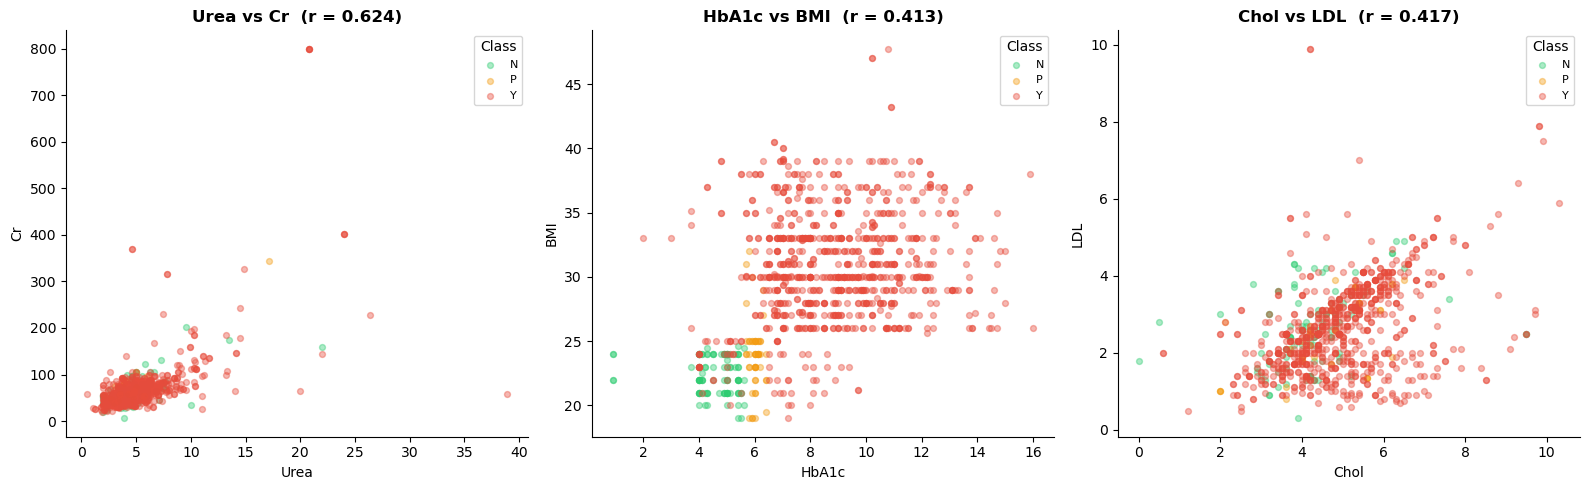

In [34]:
# Scatter plots for the top correlated pairs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('Urea', 'Cr'), ('HbA1c', 'BMI'), ('Chol', 'LDL')]
for ax, (x, y) in zip(axes, pairs):
    for cls, color in palette.items():
        subset = df[df['CLASS'] == cls]
        ax.scatter(subset[x], subset[y], alpha=0.4, s=18,
                   color=color, label=cls)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    r = df[x].corr(df[y])
    ax.set_title(f'{x} vs {y}  (r = {r:.3f})', fontweight='bold')
    ax.legend(title='Class', fontsize=8)

plt.tight_layout()
plt.show()

In [35]:
#feature analysis 


#What percentage of younger people are prone to diabetes?
young = df[df['AGE'] < 30]
young_diabetic_pct = (young['CLASS'] == 'Y').sum() / len(young) * 100
print(f'Patients under 30: {len(young)}')
print(f'Diabetic among under-30: {(young["CLASS"]=="Y").sum()}')
print(f'Diabetic rate under-30: {young_diabetic_pct:.1f}%')

#which gender is more prone to diabetes?
for gender in ['M', 'F']:
    g = df[df['Gender'] == gender]
    rate = (g['CLASS'] == 'Y').sum() / len(g) * 100
    print(f'{gender}: {len(g)} patients — {rate:.1f}% diabetic')





Patients under 30: 7
Diabetic among under-30: 5
Diabetic rate under-30: 71.4%
M: 565 patients — 86.7% diabetic
F: 435 patients — 81.4% diabetic


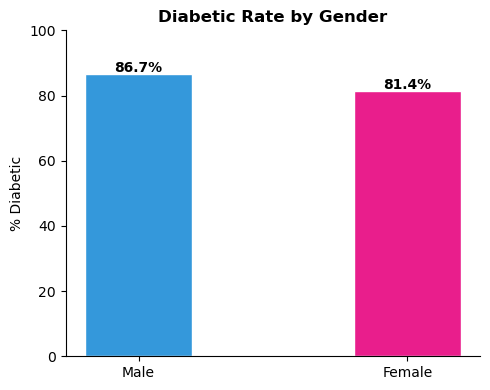

In [36]:
# Visualize diabetic rate by gender
rates = {
    g: (df[df['Gender'] == g]['CLASS'] == 'Y').sum() / len(df[df['Gender'] == g]) * 100
    for g in ['M', 'F']
}
plt.figure(figsize=(5, 4))
plt.bar(['Male', 'Female'], list(rates.values()),
        color=['#3498db', '#e91e8c'], edgecolor='white', width=0.4)
for i, (k, v) in enumerate(rates.items()):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Diabetic Rate by Gender', fontweight='bold')
plt.ylabel('% Diabetic')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

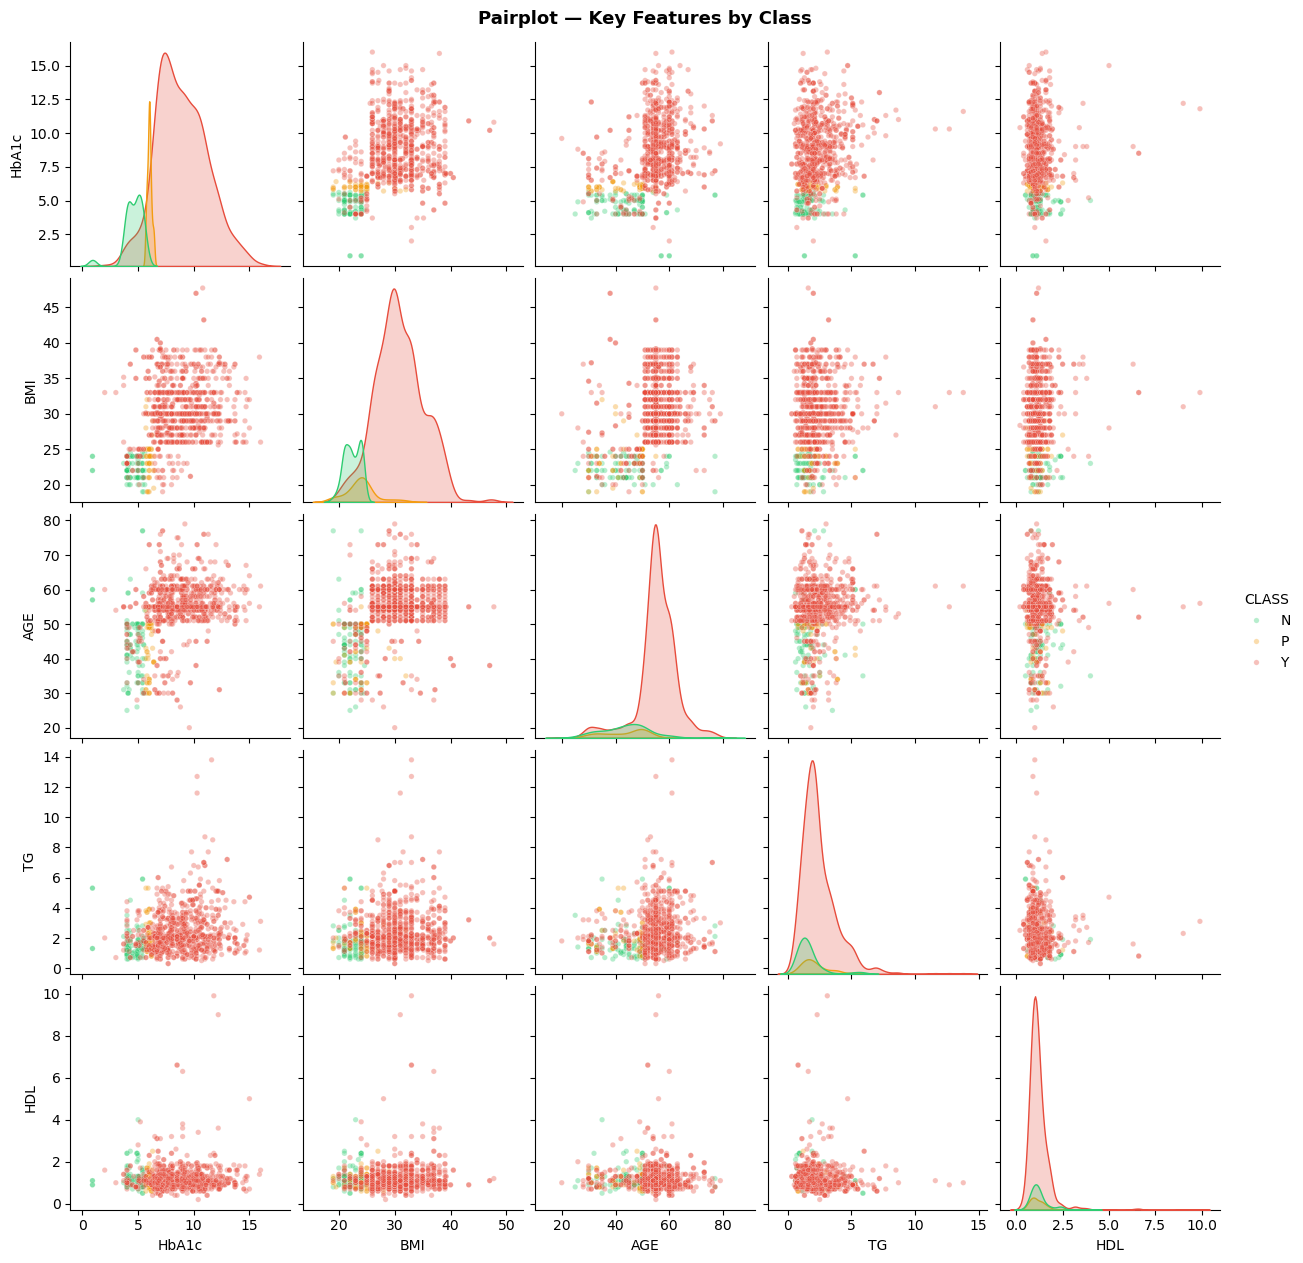

In [37]:
# Pairplot for the most important features
pairplot_df = df[['HbA1c', 'BMI', 'AGE', 'TG', 'HDL', 'CLASS']].copy()

g = sns.pairplot(
    pairplot_df,
    hue='CLASS',
    hue_order=['N', 'P', 'Y'],
    palette=palette,
    plot_kws={'alpha': 0.35, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot — Key Features by Class', y=1.01, fontsize=13, fontweight='bold')
plt.show()

In [38]:
print('=' * 55)
print('       EDA SUMMARY — KEY OBSERVATIONS')
print('=' * 55)

print(f"""
Dataset:
  Records       : {len(df)}
  Features      : {df.shape[1]}
  Missing values: {df.isnull().sum().sum()}

Class Imbalance:
  Diabetic  (Y) : {(df['CLASS']=='Y').sum()} ({(df['CLASS']=='Y').mean()*100:.1f}%)
  Non-Diab  (N) : {(df['CLASS']=='N').sum()} ({(df['CLASS']=='N').mean()*100:.1f}%)
  Pre-Diab  (P) : {(df['CLASS']=='P').sum()} ({(df['CLASS']=='P').mean()*100:.1f}%)
  --> Will need SMOTE or class-weighted models

Best Separating Features (by mean difference across classes):
  HbA1c : N=4.56, P=6.00, Y=8.88  <-- strongest signal
  BMI   : N=22.4, P=23.9, Y=30.8
  AGE   : N=44.2, P=43.3, Y=55.3

Potential Outliers:
  Cr max = 800  (IQR: 48–73)
  Urea max = 38.9  (IQR: 3.7–5.7)
  VLDL max = 35    (IQR: 0.7–1.5)

Correlations of note:
  Urea <-> Cr  : 0.624  (multicollinearity risk)
  HbA1c <-> BMI: 0.413
  HbA1c <-> AGE: 0.379
  Chol <-> LDL : 0.417

Gender:
  Males  : {(df[df['Gender']=='M']['CLASS']=='Y').mean()*100:.1f}% diabetic
  Females: {(df[df['Gender']=='F']['CLASS']=='Y').mean()*100:.1f}% diabetic

Data Quality Issues Fixed:
  - Gender 'f' normalized to 'F'
  - Trailing whitespace removed from CLASS column
""")

       EDA SUMMARY — KEY OBSERVATIONS

Dataset:
  Records       : 1000
  Features      : 15
  Missing values: 0

Class Imbalance:
  Diabetic  (Y) : 844 (84.4%)
  Non-Diab  (N) : 103 (10.3%)
  Pre-Diab  (P) : 53 (5.3%)
  --> Will need SMOTE or class-weighted models

Best Separating Features (by mean difference across classes):
  HbA1c : N=4.56, P=6.00, Y=8.88  <-- strongest signal
  BMI   : N=22.4, P=23.9, Y=30.8
  AGE   : N=44.2, P=43.3, Y=55.3

Potential Outliers:
  Cr max = 800  (IQR: 48–73)
  Urea max = 38.9  (IQR: 3.7–5.7)
  VLDL max = 35    (IQR: 0.7–1.5)

Correlations of note:
  Urea <-> Cr  : 0.624  (multicollinearity risk)
  HbA1c <-> BMI: 0.413
  HbA1c <-> AGE: 0.379
  Chol <-> LDL : 0.417

Gender:
  Males  : 86.7% diabetic
  Females: 81.4% diabetic

Data Quality Issues Fixed:
  - Gender 'f' normalized to 'F'
  - Trailing whitespace removed from CLASS column

